# NS06 Tutorial C - Comparing Centrality Measures

**Learning goals**
- Use the same notation and terminology as the NS06 slides.
- Compute and interpret **degree**, **closeness**, **harmonic**, **betweenness**, and **coreness**.
- Quantify how rankings change when the notion of centrality changes.
- Connect each centrality to a structural role on one empirical network and one synthetic graph family.

**Outline**
1. Warm-up on Zachary Karate Club.
2. Local influence, geometric proximity, and brokerage.
3. Compare all five NS06 measures on one empirical network.
4. Dumbbell graph: one structure, multiple winners.
5. Disconnected dumbbell: harmonic centrality versus lecture closeness.
6. Exercise and takeaway.

In [1]:
from netsci_utils import *
import pandas as pd

set_seeds()


def top_table(metric_dict, name, top=5):
    df = pd.DataFrame({'node': list(metric_dict.keys()), name: list(metric_dict.values())})
    return df.sort_values(name, ascending=False).head(top)


def lecture_closeness_on_disconnected_graph(G):
    scores = {}
    n = G.number_of_nodes()
    for u in G.nodes():
        lengths = nx.single_source_shortest_path_length(G, u)
        if len(lengths) < n:
            scores[u] = 0.0
        else:
            scores[u] = (n - 1) / sum(d for v, d in lengths.items() if v != u)
    return scores


def dumbbell_positions():
    return {
        0: (-1.2, 1.0), 1: (-1.2, -1.0), 2: (-0.1, 1.8),
        3: (0.0, 0.0), 4: (1.6, 0.0), 5: (3.2, 0.0),
        6: (4.8, 0.0), 7: (5.9, 1.8), 8: (7.0, 1.0), 9: (7.0, -1.0),
    }


def add_dumbbell_roles(G):
    roles = {}
    for node in G.nodes():
        if node in {0, 1, 2, 7, 8, 9}:
            role = 'clique_core'
        elif node in {3, 6}:
            role = 'connector'
        else:
            role = 'handle'
        G.nodes[node]['role'] = role
        roles[node] = role
    return roles

## 1. Warm-up on a real social network: Zachary Karate Club

This empirical network is useful because it is:

- small enough to visualize clearly
- rich enough for different centralities to disagree
- interpretable in social terms rather than only abstract formulas

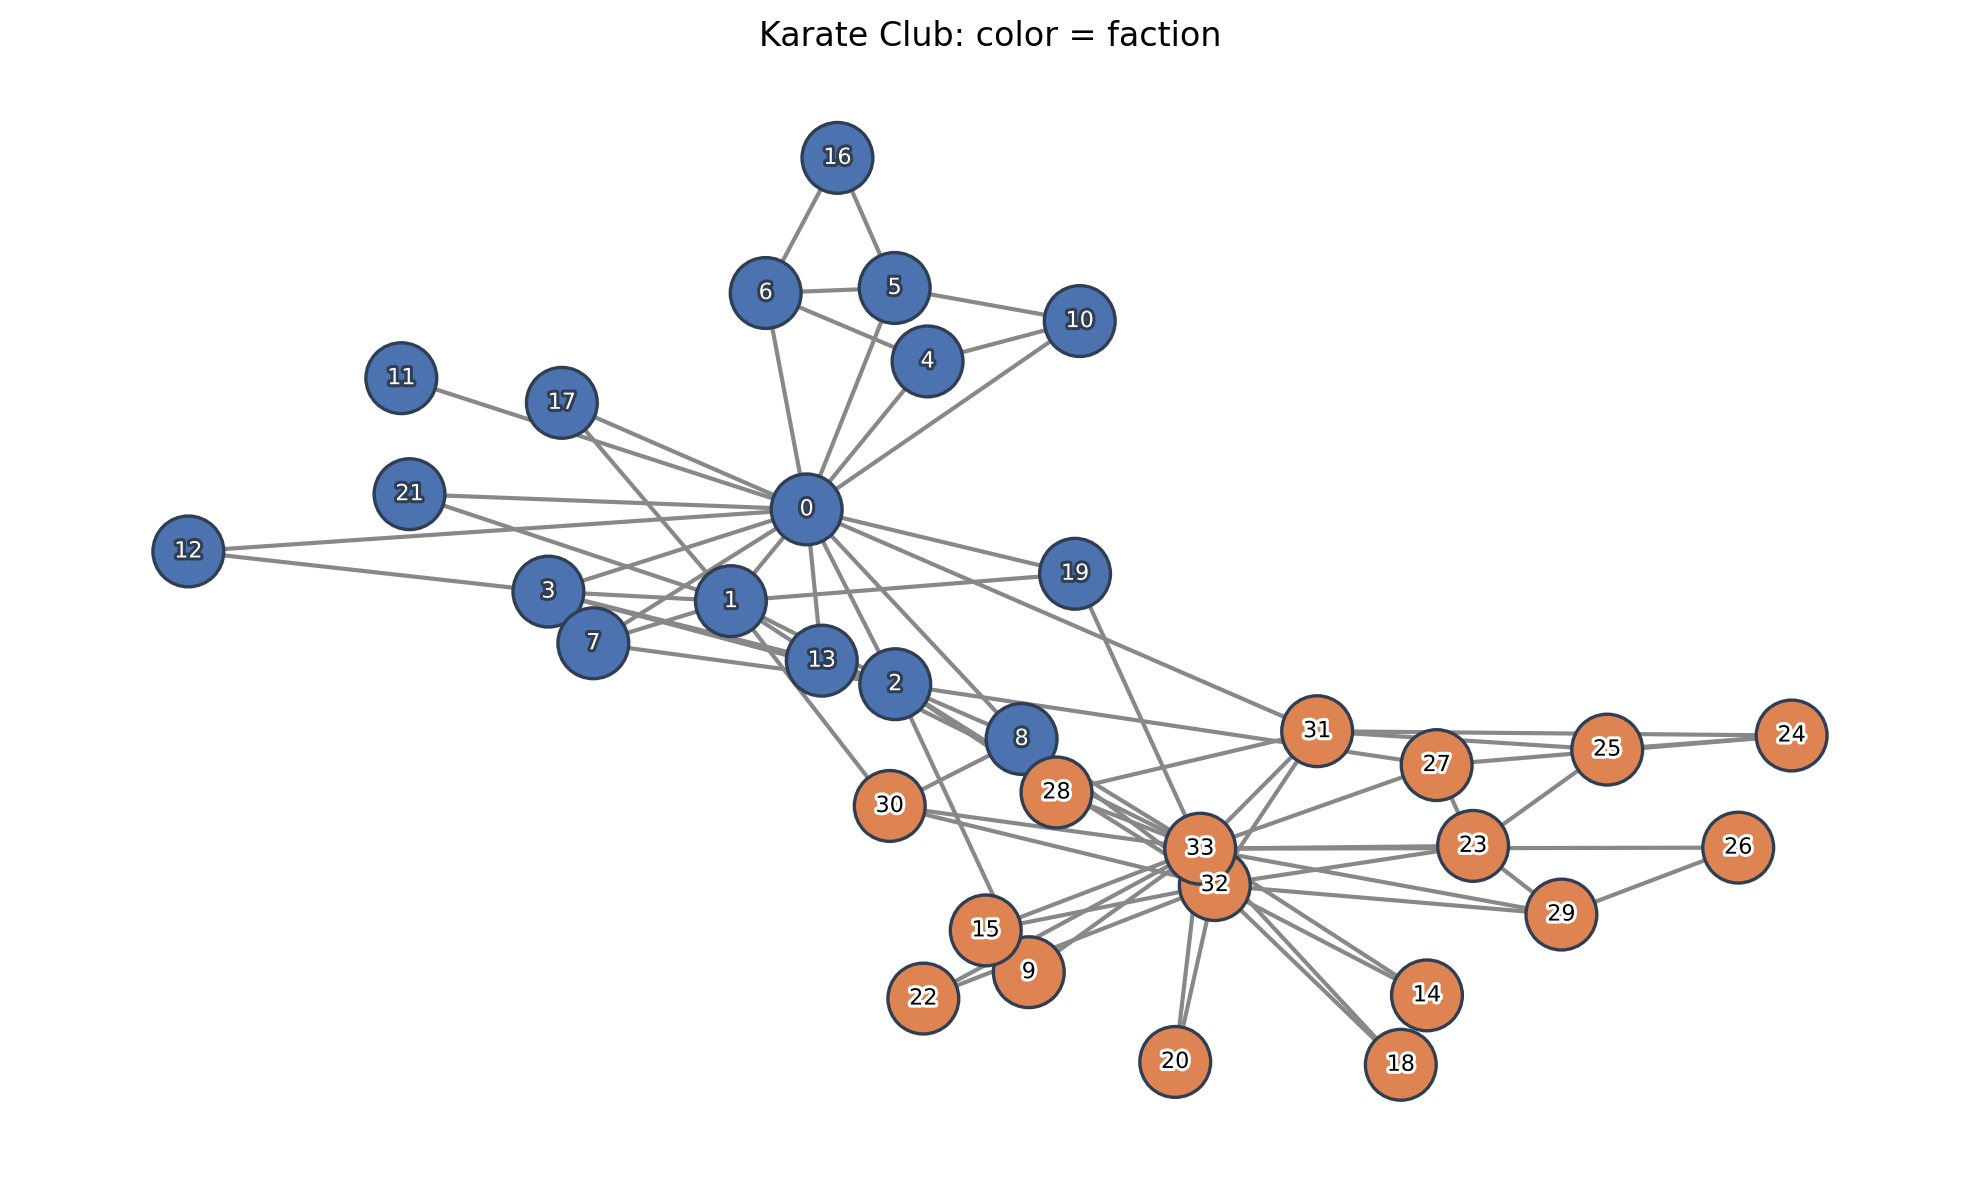

Nodes          : 34
Edges          : 78
Density        : 0.139037
Average degree : 4.5882
Avg clustering : 0.5706
Diameter       : 5


In [2]:
karate = nx.karate_club_graph()
pos_karate = nx.spring_layout(karate, seed=RANDOM_SEED)

plot_graph(
    karate,
    title='Karate Club: color = faction',
    pos=pos_karate,
    with_labels=True,
    node_color=colors_from_node_attribute(karate, 'club', KARATE_CLUB_COLORS),
    node_size=650,
    font_size=8,
)

print_network_stats(karate)

## 2. Local influence, geometric proximity, and brokerage

The first three measures already show why one notion of centrality is not enough:

- **degree** rewards local influence
- **closeness** rewards geometric proximity
- **betweenness** rewards brokerage and bottlenecks

Top nodes by degree centrality:
 node  degree
   33  0.5152
    0  0.4848
   32  0.3636
    2  0.3030
    1  0.2727
    3  0.1818


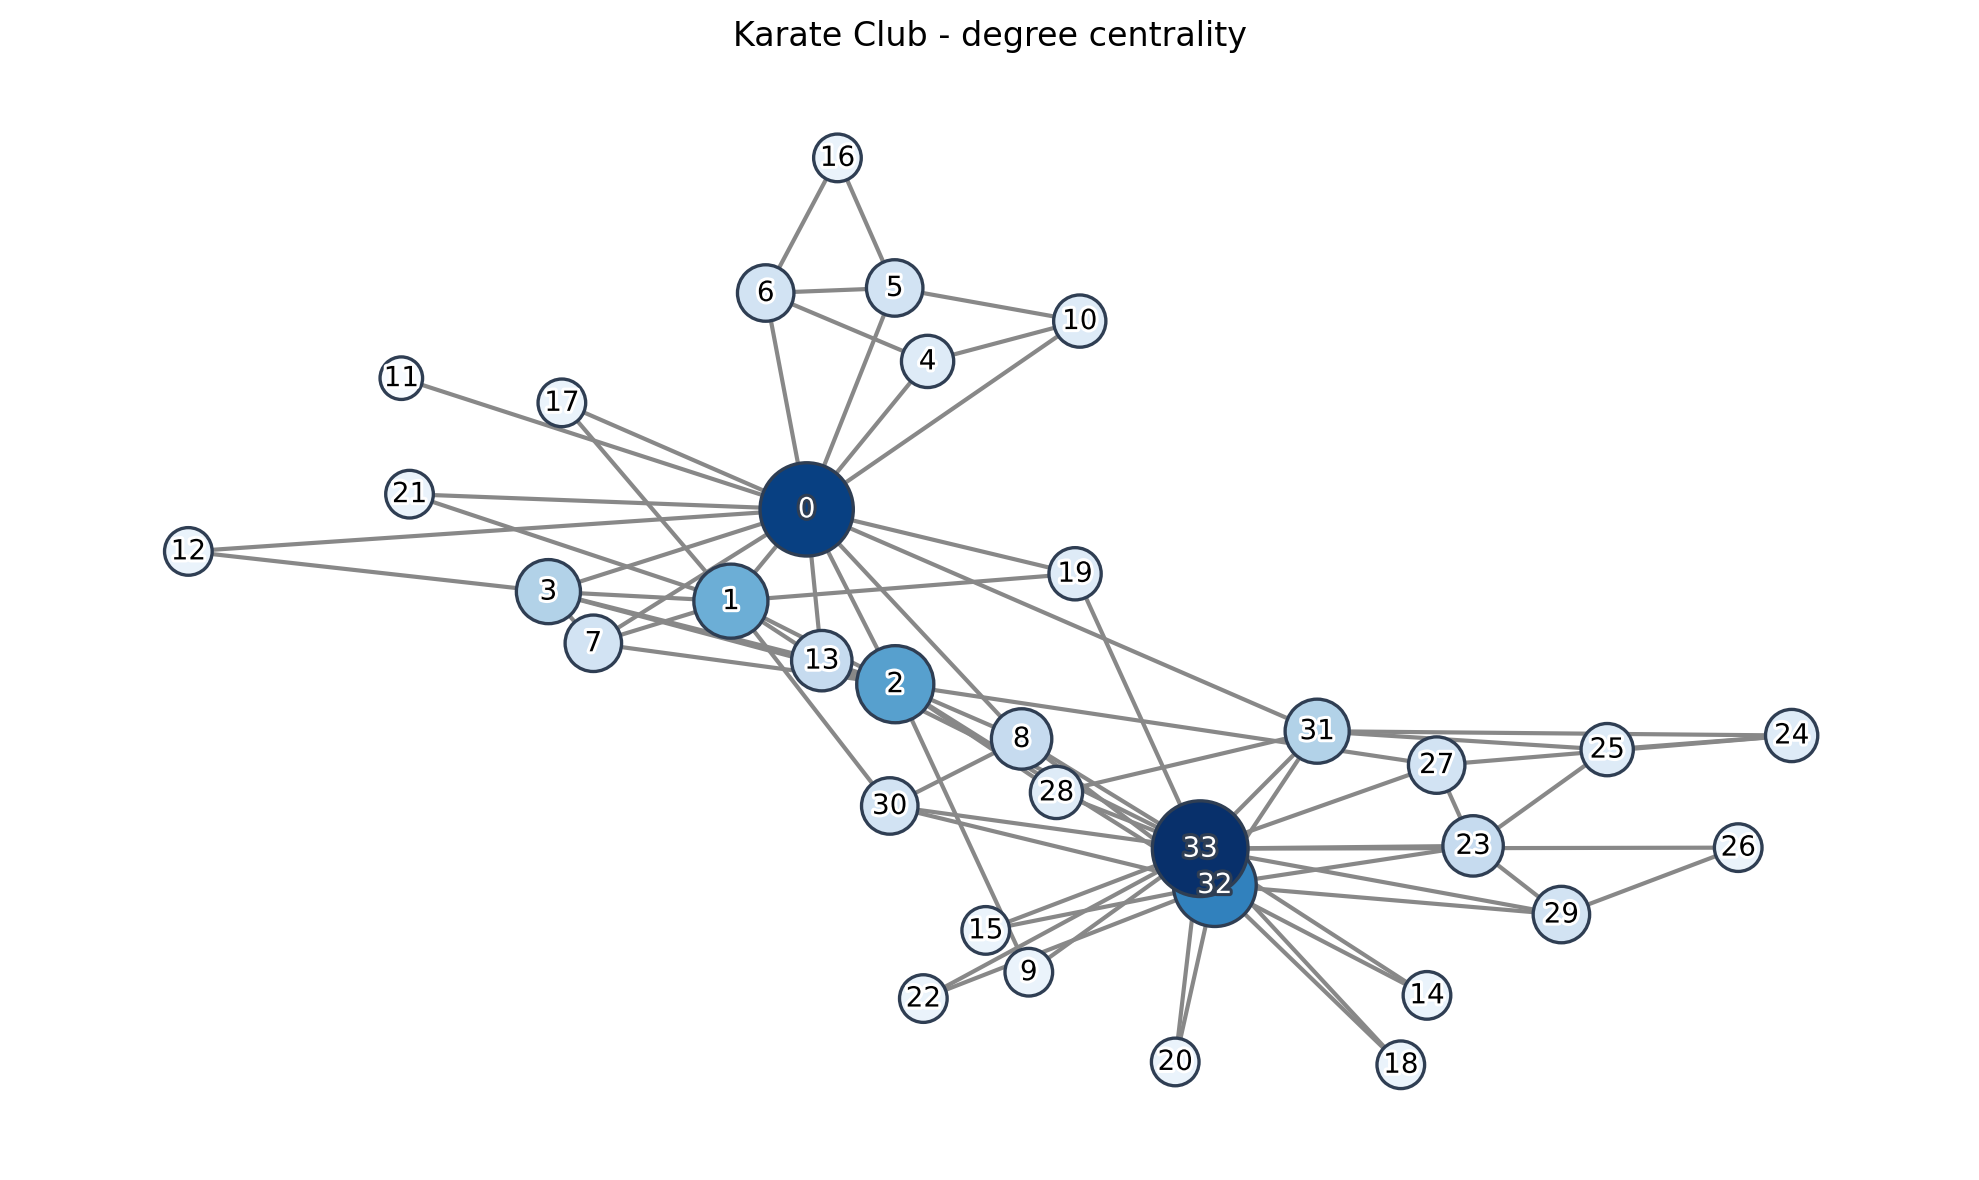


Top nodes by closeness centrality:
 node  closeness
    0     0.5690
    2     0.5593
   33     0.5500
   31     0.5410
   13     0.5156
   32     0.5156


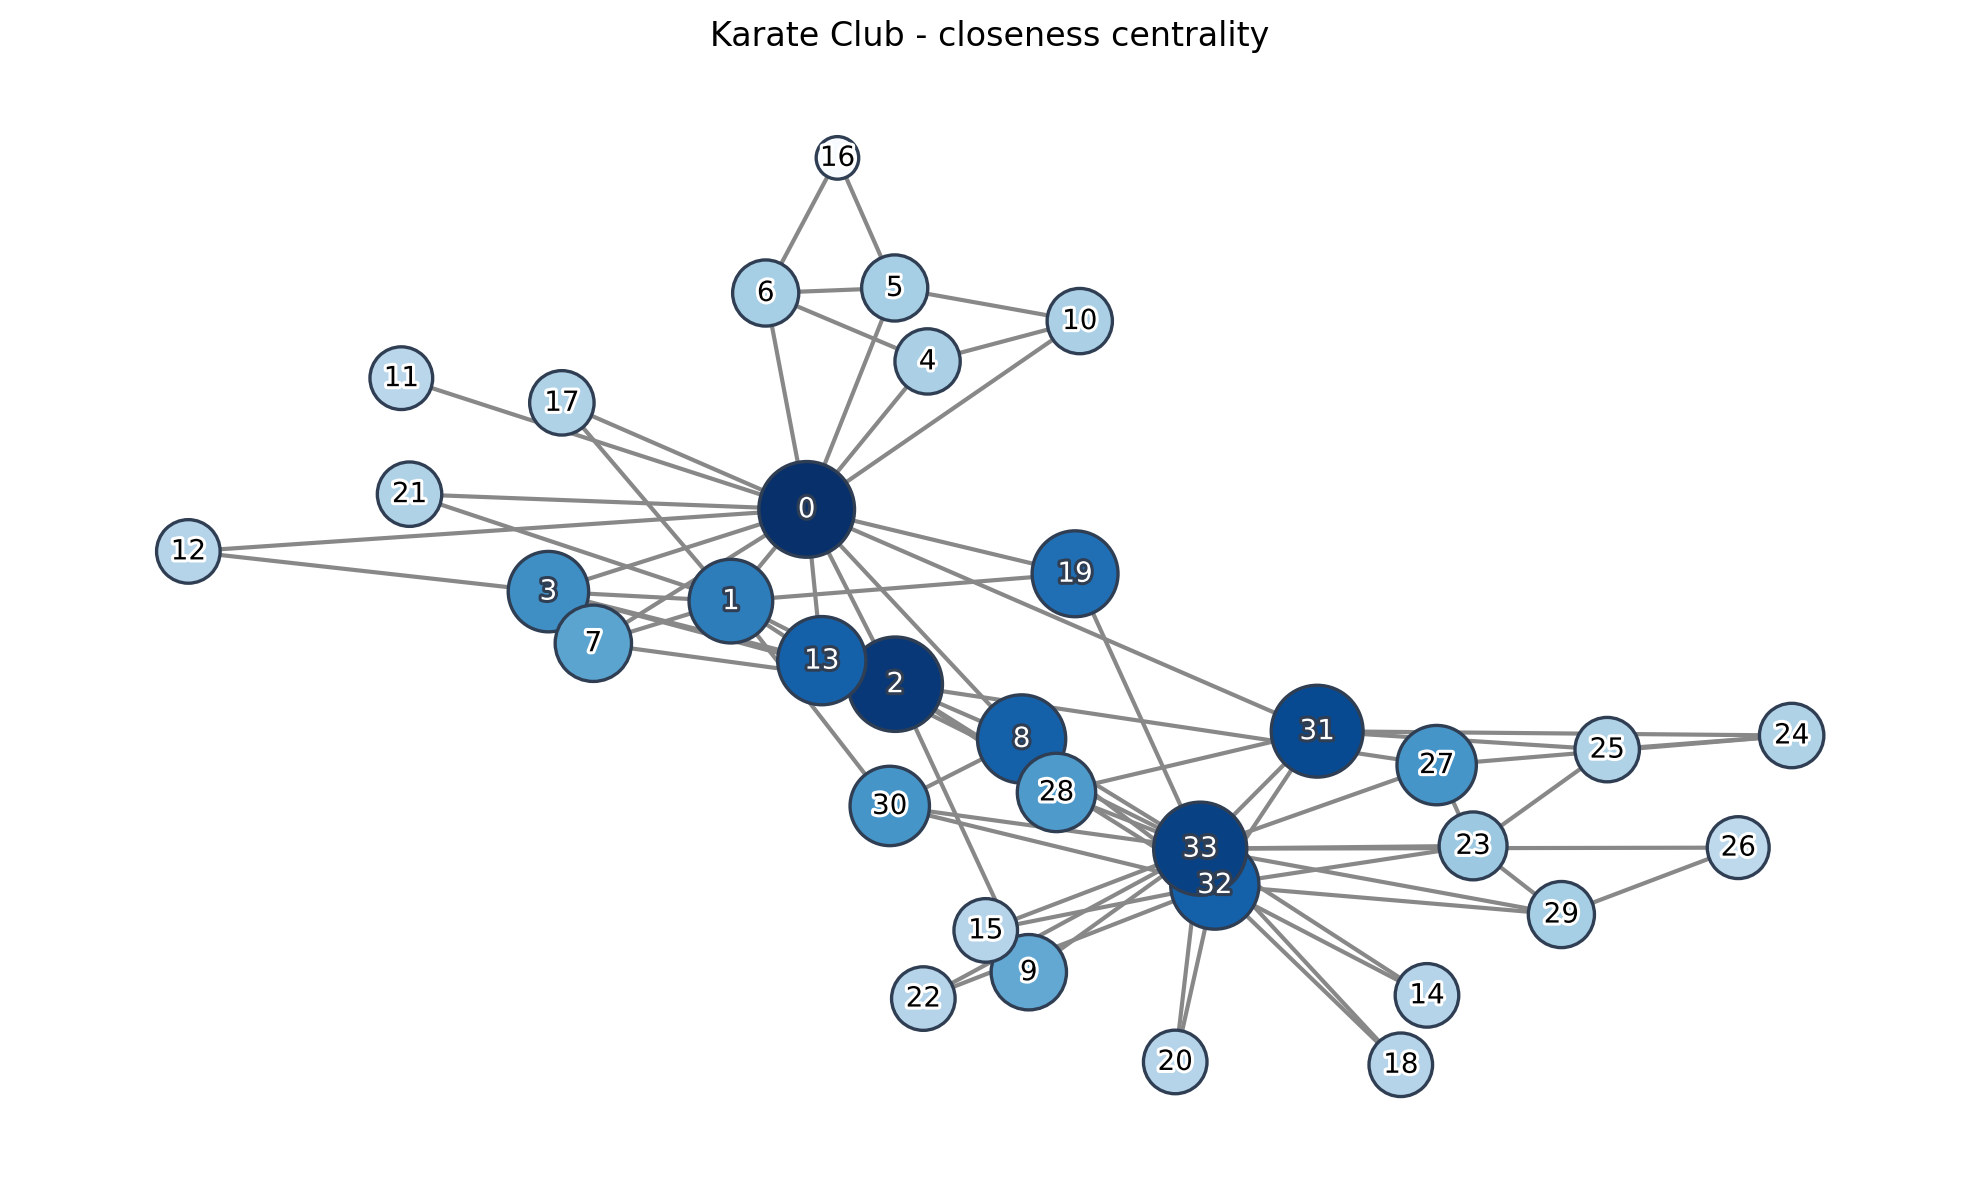


Top nodes by betweenness centrality:
 node  betweenness
    0       0.4376
   33       0.3041
   32       0.1452
    2       0.1437
   31       0.1383
    8       0.0559


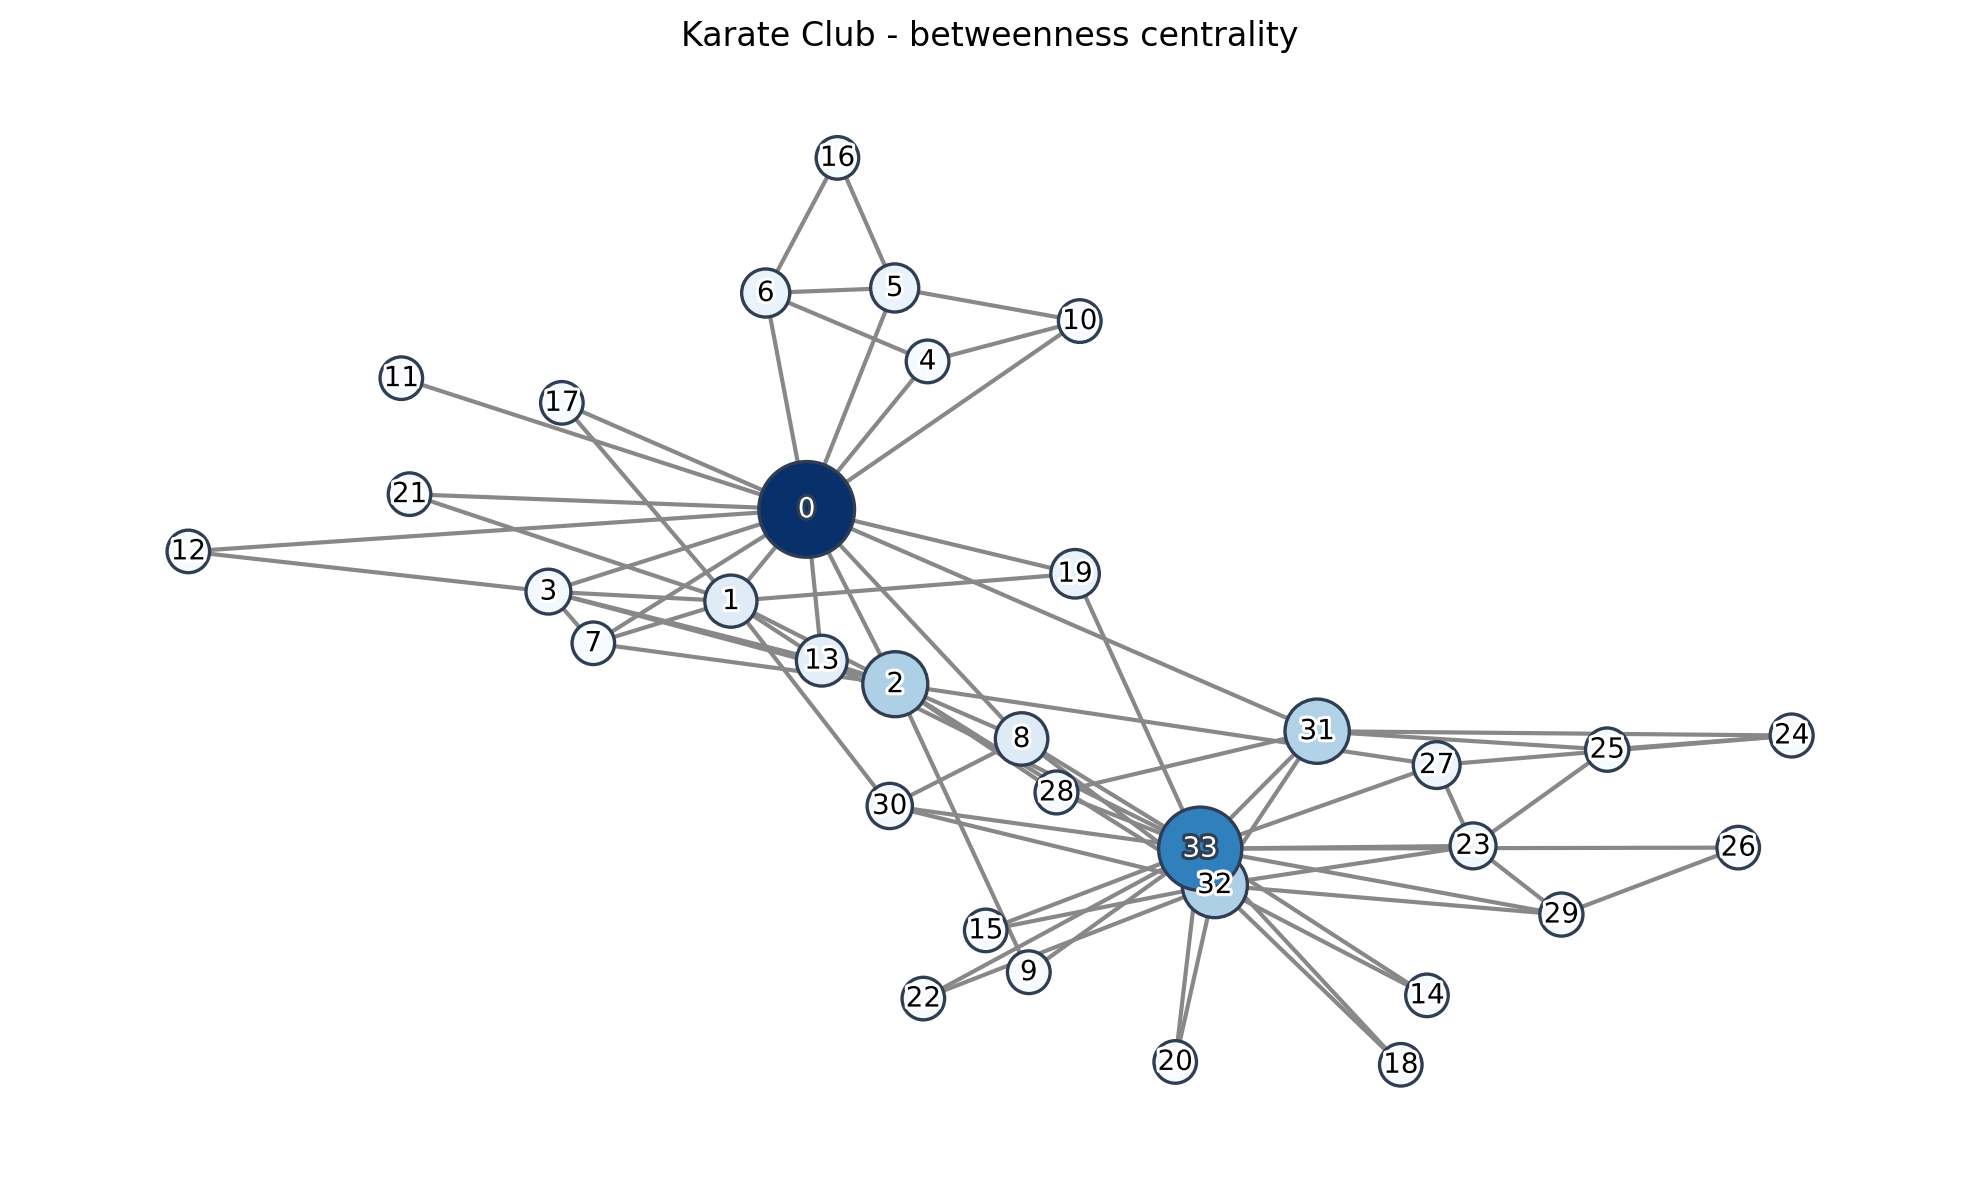

In [3]:
degree = nx.degree_centrality(karate)
closeness = nx.closeness_centrality(karate)
betweenness = nx.betweenness_centrality(karate)

print('Top nodes by degree centrality:')
print(top_table(degree, 'degree', top=6).round(4).to_string(index=False))
plot_metric(
    karate,
    degree,
    title='Karate Club - degree centrality',
    pos=pos_karate,
    with_labels=True,
    min_node_size_px=24,
    max_node_size_px=54,
)

print('\nTop nodes by closeness centrality:')
print(top_table(closeness, 'closeness', top=6).round(4).to_string(index=False))
plot_metric(
    karate,
    closeness,
    title='Karate Club - closeness centrality',
    pos=pos_karate,
    with_labels=True,
    min_node_size_px=24,
    max_node_size_px=54,
)

print('\nTop nodes by betweenness centrality:')
print(top_table(betweenness, 'betweenness', top=6).round(4).to_string(index=False))
plot_metric(
    karate,
    betweenness,
    title='Karate Club - betweenness centrality',
    pos=pos_karate,
    with_labels=True,
    min_node_size_px=24,
    max_node_size_px=54,
)

## 3. Compare all five NS06 measures on one empirical network

Harmonic centrality and coreness are especially useful when graphs are disconnected or have dense cores, but we can compute them on the Karate Club as well.

This gives a computational view of how much the five rankings agree or disagree on the same empirical network.

 node  degree  degree_rank  closeness  closeness_rank  betweenness  betweenness_rank  harmonic  harmonic_rank  coreness  coreness_rank
    0  0.4848          2.0     0.5690             1.0       0.4376               1.0   23.1667            2.0         4            1.0
   33  0.5152          1.0     0.5500             3.0       0.3041               2.0   23.2500            1.0         4            1.0
   32  0.3636          3.0     0.5156             5.0       0.1452               3.0   20.9167            4.0         4            1.0
    2  0.3030          4.0     0.5593             2.0       0.1437               4.0   21.0000            3.0         4            1.0
   31  0.1818          6.0     0.5410             4.0       0.1383               5.0   19.3333            5.0         3           11.0
    8  0.1515          8.0     0.5156             5.0       0.0559               6.0   18.5000            7.0         4            1.0
    1  0.2727          5.0     0.4853             9.0  

/Users/rschifan/Library/CloudStorage/GoogleDrive-rossano.schifanella@unito.it/My Drive/teaching/2026/complex_network/netsci/tutorials/src/netsci_utils.py:517: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(grid, alpha=0.3)


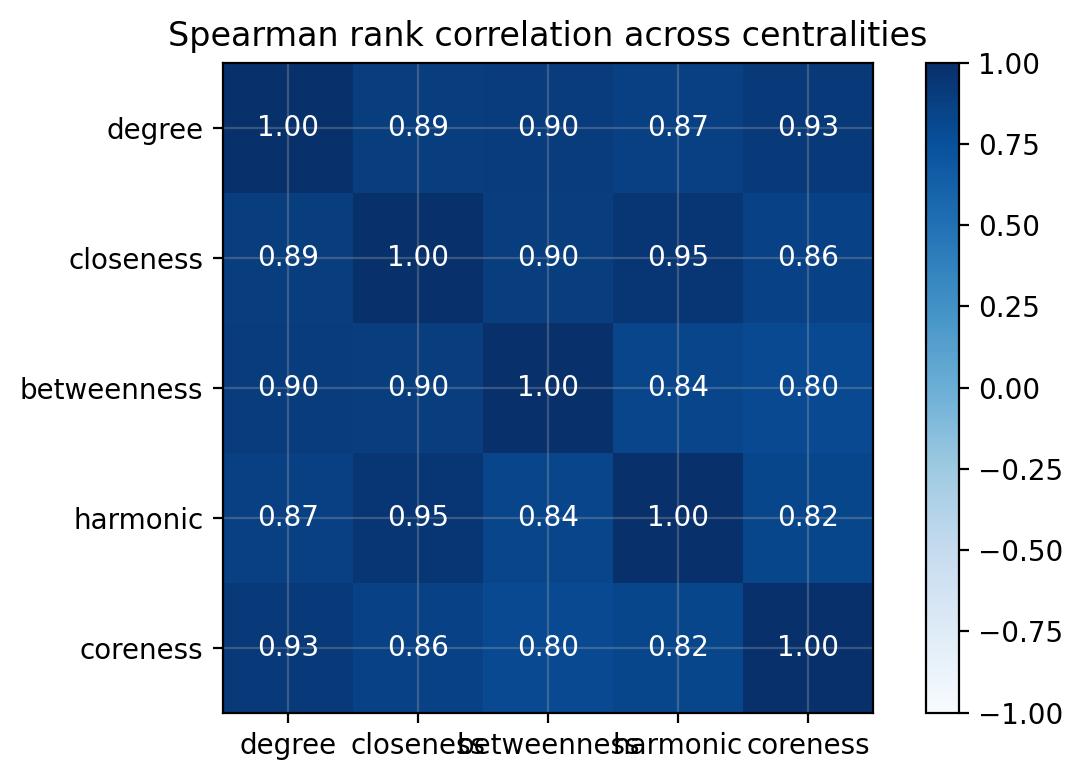

In [4]:
harmonic = nx.harmonic_centrality(karate)
coreness = nx.core_number(karate)

karate_metrics = pd.DataFrame({'node': list(karate.nodes())})
for name, values in [
    ('degree', degree),
    ('closeness', closeness),
    ('betweenness', betweenness),
    ('harmonic', harmonic),
    ('coreness', coreness),
]:
    karate_metrics[name] = karate_metrics['node'].map(values)
    karate_metrics[f'{name}_rank'] = karate_metrics[name].rank(ascending=False, method='min')

print(karate_metrics.sort_values('betweenness', ascending=False).head(10).round(4).to_string(index=False))

corr = karate_metrics[['degree', 'closeness', 'betweenness', 'harmonic', 'coreness']].corr(method='spearman')
plot_heatmap(
    corr,
    labels=['degree', 'closeness', 'betweenness', 'harmonic', 'coreness'],
    title='Spearman rank correlation across centralities',
    vmin=-1,
    vmax=1,
)
plt.show()

**Interpretation.**

The correlations are not zero, but they are far from perfect.

That is exactly the practical lesson of NS06: on a real network, the node you target changes with the task.

- outreach or influence -> often high degree
- fast reach -> high closeness / harmonic
- mediation or control of flows -> high betweenness
- resilient inner position -> high coreness

## 4. Dumbbell graph: one structure, multiple winners

The dumbbell graph is the clean synthetic example for this lecture because it contains three structural roles in one symmetric graph:

- **clique_core** nodes in the dense bells
- **connector** nodes at the mouth of each bell
- **handle** nodes in the thin bridge between the two sides

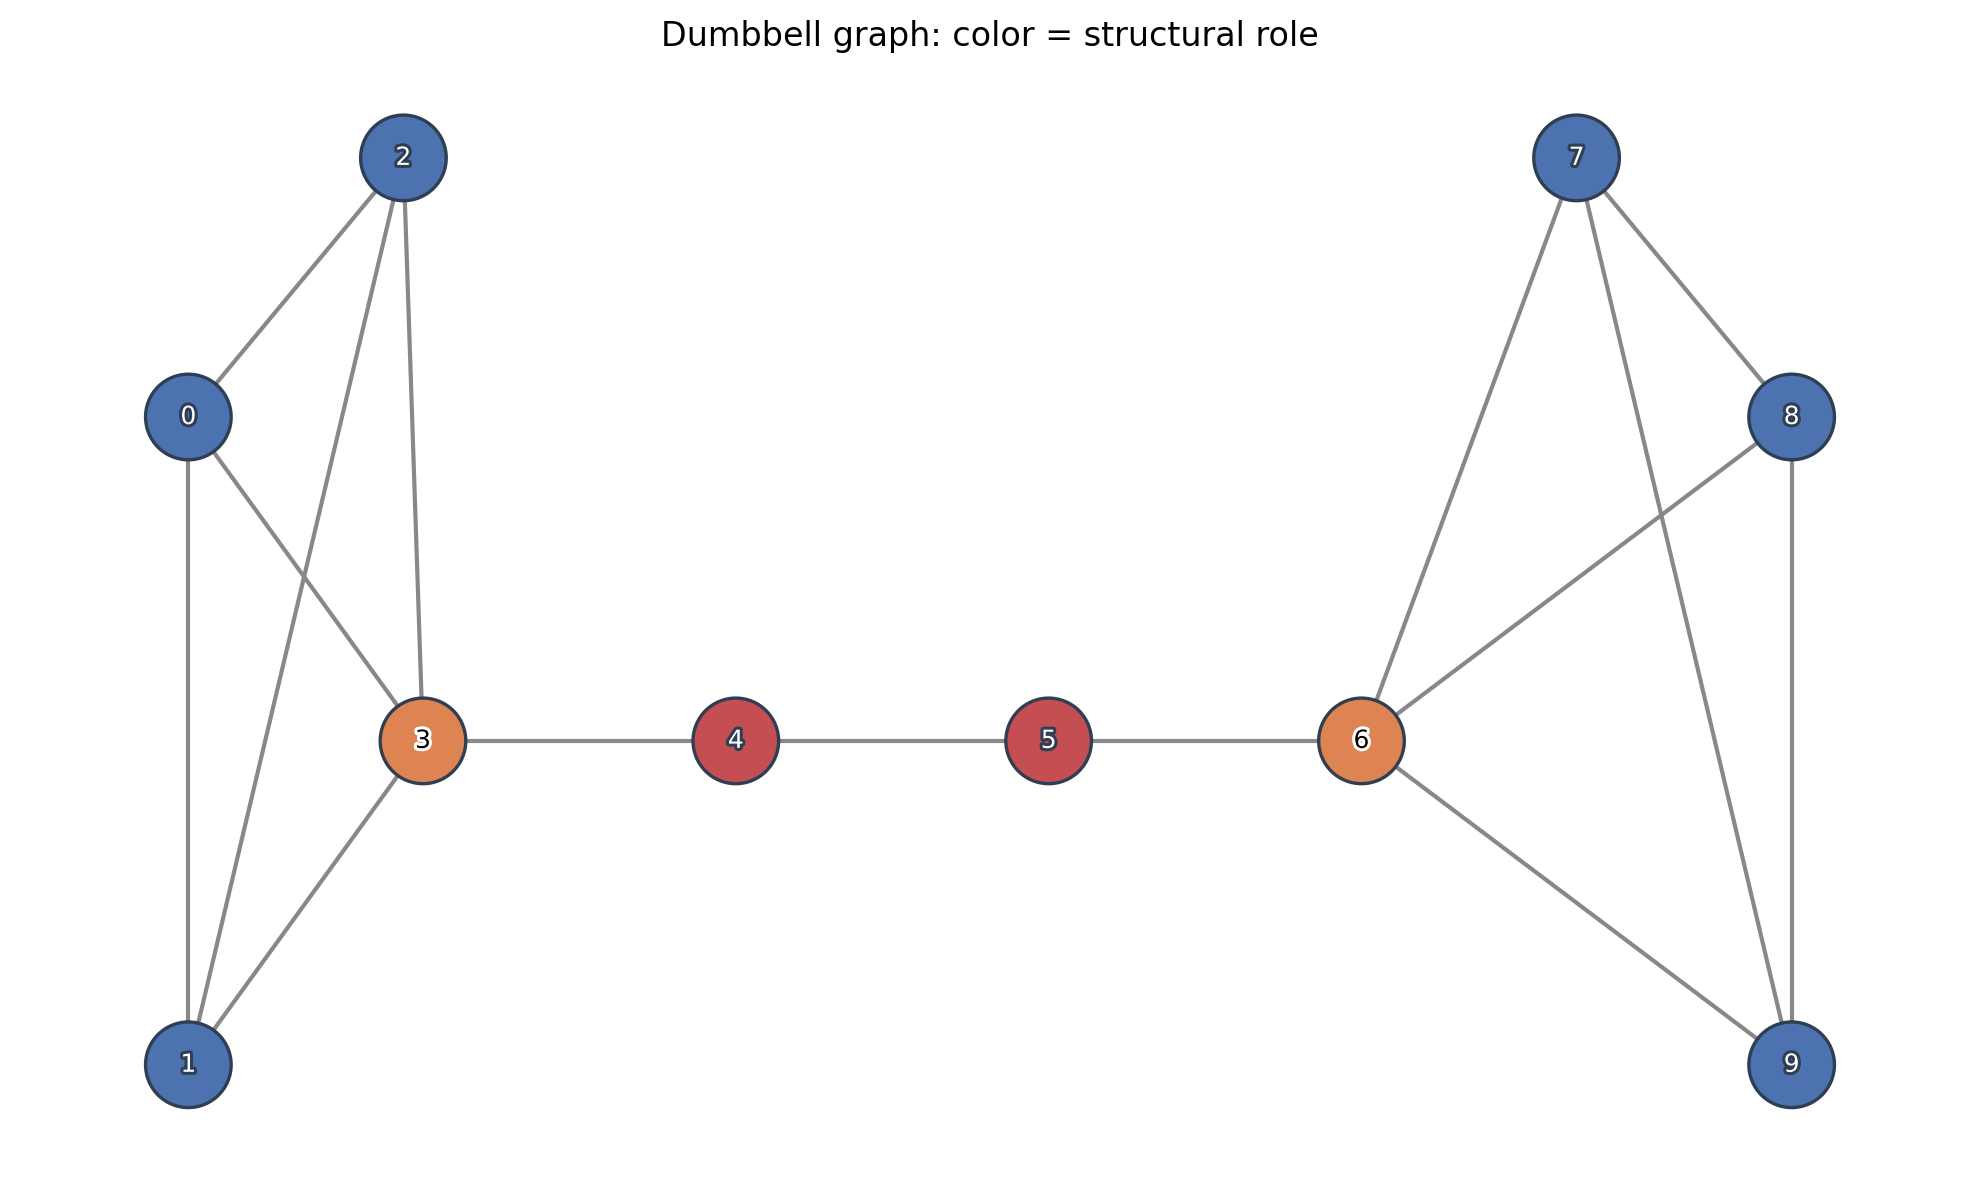

 node        role
    0 clique_core
    1 clique_core
    2 clique_core
    7 clique_core
    8 clique_core
    9 clique_core
    3   connector
    6   connector
    4      handle
    5      handle


In [5]:
dumbbell = nx.barbell_graph(4, 2)
dumbbell_roles = add_dumbbell_roles(dumbbell)
pos_dumbbell = dumbbell_positions()
role_order = {'clique_core': 0, 'connector': 1, 'handle': 2}

role_table = pd.DataFrame({
    'node': list(dumbbell.nodes()),
    'role': [dumbbell_roles[n] for n in dumbbell.nodes()],
}).sort_values(['role', 'node'])

plot_graph(
    dumbbell,
    title='Dumbbell graph: color = structural role',
    pos=pos_dumbbell,
    with_labels=True,
    node_color=colors_from_node_attribute(dumbbell, 'role', DUMBBELL_ROLE_COLORS),
    node_size=950,
    font_size=9,
)

print(role_table.to_string(index=False))

Now compute all five measures on exactly the same graph.

This isolates the main NS06 question: **which structural role does each centrality reward?**

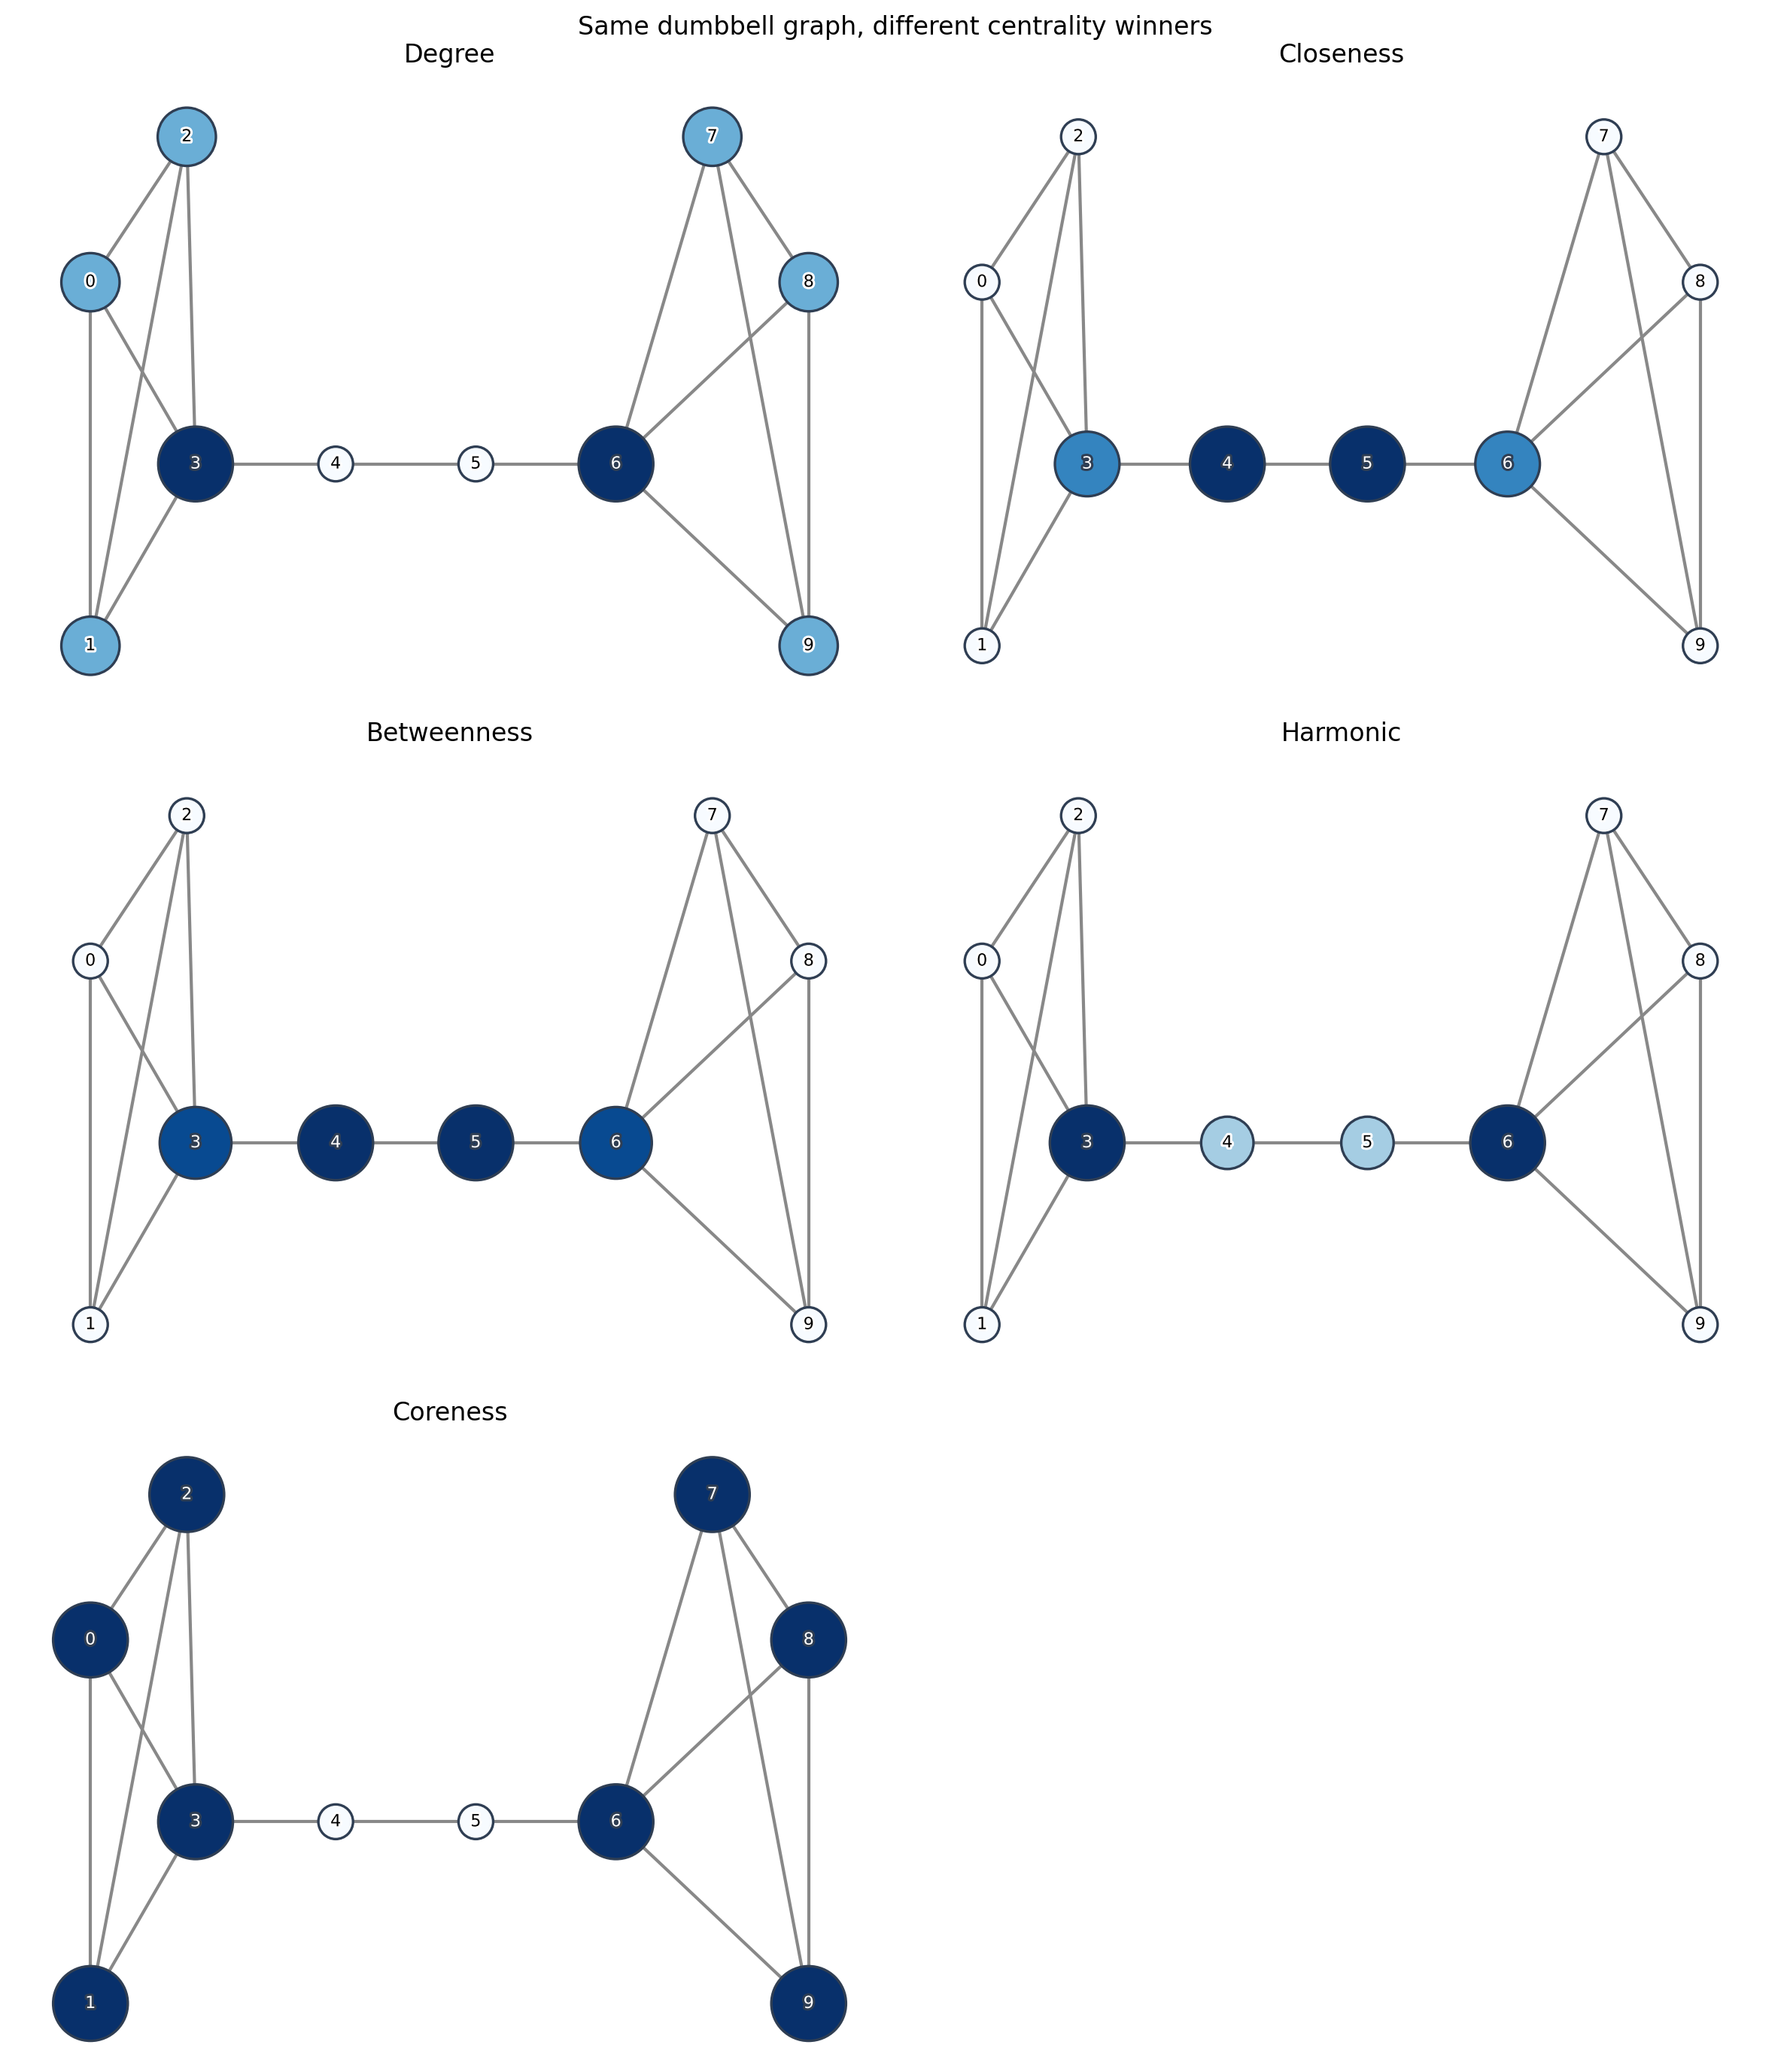

 node        role  degree  degree_rank  closeness  closeness_rank  betweenness  betweenness_rank  harmonic  harmonic_rank  coreness  coreness_rank
    0 clique_core  0.3333          3.0     0.3333             5.0       0.0000               5.0    4.6833            5.0         3            1.0
    1 clique_core  0.3333          3.0     0.3333             5.0       0.0000               5.0    4.6833            5.0         3            1.0
    2 clique_core  0.3333          3.0     0.3333             5.0       0.0000               5.0    4.6833            5.0         3            1.0
    7 clique_core  0.3333          3.0     0.3333             5.0       0.0000               5.0    4.6833            5.0         3            1.0
    8 clique_core  0.3333          3.0     0.3333             5.0       0.0000               5.0    4.6833            5.0         3            1.0
    9 clique_core  0.3333          3.0     0.3333             5.0       0.0000               5.0    4.6833            

In [6]:
dumbbell_degree = nx.degree_centrality(dumbbell)
dumbbell_closeness = nx.closeness_centrality(dumbbell)
dumbbell_betweenness = nx.betweenness_centrality(dumbbell)
dumbbell_harmonic = nx.harmonic_centrality(dumbbell)
dumbbell_coreness = nx.core_number(dumbbell)

metrics = [
    ('degree', dumbbell_degree),
    ('closeness', dumbbell_closeness),
    ('betweenness', dumbbell_betweenness),
    ('harmonic', dumbbell_harmonic),
    ('coreness', dumbbell_coreness),
]

dumbbell_table = pd.DataFrame({
    'node': list(dumbbell.nodes()),
    'role': [dumbbell_roles[n] for n in dumbbell.nodes()],
})
for name, values in metrics:
    dumbbell_table[name] = dumbbell_table['node'].map(values)
    dumbbell_table[f'{name}_rank'] = dumbbell_table[name].round(10).rank(ascending=False, method='min')

dumbbell_table['role_order'] = dumbbell_table['role'].map(role_order)
dumbbell_table = dumbbell_table.sort_values(['role_order', 'node']).drop(columns='role_order')

fig, axes = plt.subplots(3, 2, figsize=(12, 14))
for ax, (name, values) in zip(axes.flat, metrics):
    draw_graph_metric(
        dumbbell,
        values,
        pos=pos_dumbbell,
        ax=ax,
        with_labels=True,
        font_size=8,
        colorbar=False,
        min_node_size_px=26,
        max_node_size_px=56,
    )
    ax.set_title(name.capitalize(), pad=10)
axes.flat[-1].axis('off')
plt.subplots_adjust(hspace=0.3, wspace=0.16)
plt.suptitle('Same dumbbell graph, different centrality winners', y=0.98)
plt.show()

print(dumbbell_table.round(4).to_string(index=False))

This graph makes the lecture logic concrete:

- **degree** is highest on the **connector** nodes
- **closeness** and **betweenness** are highest on the **handle** nodes
- **harmonic** is highest on the **connector** nodes
- **coreness** is highest on the dense bells, including the connectors

One structure, several different notions of centrality.

## 5. Disconnected dumbbell: harmonic centrality versus lecture closeness

Now remove one edge from the handle. The graph splits into two components, but the node roles stay the same.

This is exactly the situation in which the lecture definition of closeness collapses to zero, while **harmonic centrality** remains informative.

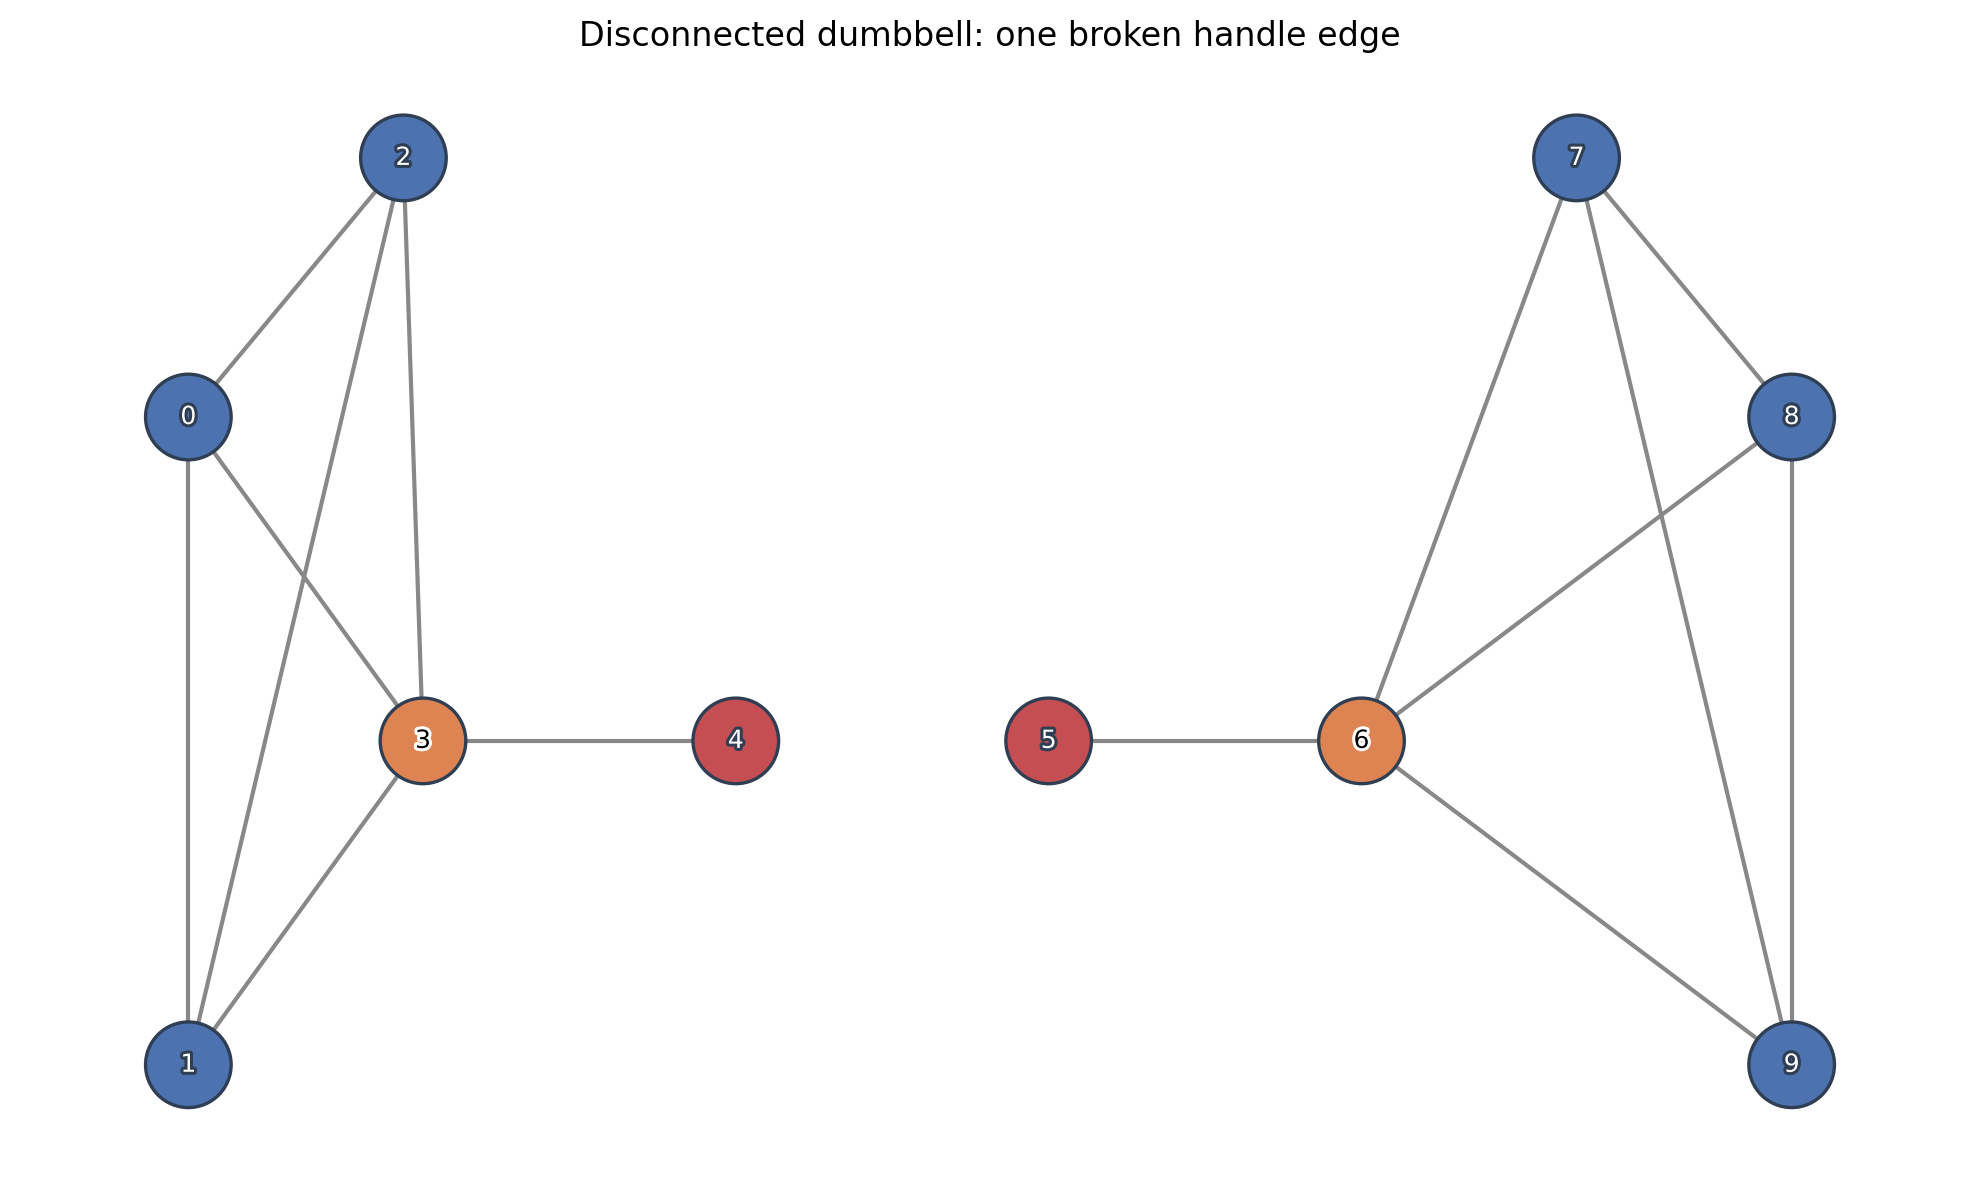

 node        role  lecture_closeness  harmonic
    3   connector                0.0       4.0
    6   connector                0.0       4.0
    0 clique_core                0.0       3.5
    1 clique_core                0.0       3.5
    2 clique_core                0.0       3.5
    7 clique_core                0.0       3.5
    8 clique_core                0.0       3.5
    9 clique_core                0.0       3.5
    4      handle                0.0       2.5
    5      handle                0.0       2.5


In [7]:
dumbbell_cut = dumbbell.copy()
dumbbell_cut.remove_edge(4, 5)

cut_closeness = lecture_closeness_on_disconnected_graph(dumbbell_cut)
cut_harmonic = nx.harmonic_centrality(dumbbell_cut)
cut_table = pd.DataFrame({
    'node': list(dumbbell_cut.nodes()),
    'role': [dumbbell_cut.nodes[n]['role'] for n in dumbbell_cut.nodes()],
    'lecture_closeness': [cut_closeness[n] for n in dumbbell_cut.nodes()],
    'harmonic': [cut_harmonic[n] for n in dumbbell_cut.nodes()],
})
cut_table['role_order'] = cut_table['role'].map(role_order)
cut_table = cut_table.sort_values(['harmonic', 'role_order', 'node'], ascending=[False, True, True]).drop(columns='role_order')

plot_graph(
    dumbbell_cut,
    title='Disconnected dumbbell: one broken handle edge',
    pos=pos_dumbbell,
    with_labels=True,
    node_color=colors_from_node_attribute(dumbbell_cut, 'role', DUMBBELL_ROLE_COLORS),
    node_size=950,
    font_size=9,
)

print(cut_table.round(4).to_string(index=False))

## 6. Exercise

Before running the next cell, predict:

- which role disappears from the top when we move from **coreness** to **betweenness**?
- which nodes stay strongest under **harmonic centrality** after the cut?
- why do all lecture-style closeness scores become **0**?

In [8]:
print('Top nodes by each centrality on the connected dumbbell:')
for name, values in metrics:
    max_value = max(values.values())
    winners = [n for n, value in values.items() if abs(value - max_value) < 1e-12]
    print(f'  {name:<11} -> nodes {winners}, roles {sorted({dumbbell_roles[n] for n in winners})}')

print('\nDisconnected dumbbell checks:')
print(f"  lecture_closeness all zero: {all(value == 0 for value in cut_closeness.values())}")
max_harmonic = max(cut_harmonic.values())
harmonic_winners = [n for n, value in cut_harmonic.items() if abs(value - max_harmonic) < 1e-12]
print(f'  harmonic winners after the cut: {harmonic_winners}')
print(f"  their roles: {sorted({dumbbell_cut.nodes[n]['role'] for n in harmonic_winners})}")

Top nodes by each centrality on the connected dumbbell:
  degree      -> nodes [3, 6], roles ['connector']
  closeness   -> nodes [4, 5], roles ['handle']
  betweenness -> nodes [4, 5], roles ['handle']
  harmonic    -> nodes [3, 6], roles ['connector']
  coreness    -> nodes [0, 1, 2, 3, 6, 7, 8, 9], roles ['clique_core', 'connector']

Disconnected dumbbell checks:
  lecture_closeness all zero: True
  harmonic winners after the cut: [3, 6]
  their roles: ['connector']


## Takeaway

There is no single best centrality measure.

Choose the one that matches the structural role you care about:

- **degree** -> local influence / hubs
- **closeness** -> geometric proximity / diffusion speed
- **harmonic** -> closeness when disconnectedness matters
- **betweenness** -> brokerage / bottlenecks
- **coreness** -> structural embeddedness

For **recursive importance** and **status/prestige**, go back to Tutorial 06A (eigenvector) and Tutorial 06B (Katz).